# Cairo Real Estate — Data Cleaning Notebook
**Author:** Marwan Ashraf  
**Last updated:** 5/19/2026 
**Purpose:** Exploratory cleaning notebook to identify what transformations are needed before building the final cleaner script.

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import yaml


In [122]:
with open('../config.yaml', 'r') as f:
    config = yaml.safe_load(f)

In [3]:
df = pd.read_csv(config['data_source']['file_paths']['raw_file'])
df.info()

C:\Users\marwa\AppData\Local\Temp\ipykernel_1208\2548498825.py:1: DtypeWarning: Columns (11,12,15,20,24,25,26,42,43) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(config['data_source']['file_paths']['raw_file'])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70534 entries, 0 to 70533
Data columns (total 44 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   title                        70532 non-null  object 
 1   city                         70534 non-null  object 
 2   district                     70534 non-null  object 
 3   area                         63943 non-null  object 
 4   neighborhood                 40712 non-null  object 
 5   property_type                70534 non-null  object 
 6   sale_or_rent                 70534 non-null  object 
 7   price                        70344 non-null  object 
 8   seller_name                  70534 non-null  object 
 9   area (mÂ²)                   0 non-null      float64
 10  property_subtype             70344 non-null  object 
 11  bedrooms                     70344 non-null  object 
 12  bathrooms                    70344 non-null  object 
 13  purpose         

In [4]:
null_titles = df[df['title'].isnull()]


In [4]:
pd.set_option('display.max_columns', None)

In [6]:
null_titles.head()

,title,city,district,area,neighborhood,property_type,sale_or_rent,price,seller_name,area (mÂ²),property_subtype,bedrooms,bathrooms,purpose,ownership,level,payment option,furnished,completion status,delivery term,delivery date,monthly installments,payment period (years),price type,deposit,insurance,rental frequency,electricity meter,water meter,covered parking,natural gas,security,pets allowed,balcony,private garden,pool,landline,maids room,built in kitchen appliances,elevator,central a/c & heating,listing_date,area (m²),compound
63142,NaN,Cairo,Mostakbal City,Aliva mostakbal city,NaN,villas,sale,"EGP 23,000,000",This ad is no longer available,NaN,iVilla,4,4,for sale,NaN,NaN,installment,NaN,ready,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,True,True,True,True,True,False,True,True,True,False,True,False,False,4/27/2026,310,NaN
66992,NaN,Cairo,Katameya,West Golf Compound,NaN,villas,sale,"EGP 75,000,000",Kemet Real Estate,NaN,Stand Alone Villa,10+,10+,for sale,resale,NaN,cash,yes,ready,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,4/30/2026,"2,500",NaN


In [5]:
price_type = df['price type'].value_counts()
price_type

price type
negotiable    1158
Name: count, dtype: int64

## 1. Drop Irrelevant Columns

In [ ]:
df = df.drop(columns = ['compound','area (mÂ²)','monthly installments', 'payment period (years)', 'price type'])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70534 entries, 0 to 70533
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   title                        70532 non-null  object
 1   city                         70534 non-null  object
 2   district                     70534 non-null  object
 3   area                         63943 non-null  object
 4   neighborhood                 40712 non-null  object
 5   property_type                70534 non-null  object
 6   sale_or_rent                 70534 non-null  object
 7   price                        70344 non-null  object
 8   seller_name                  70534 non-null  object
 9   property_subtype             70344 non-null  object
 10  bedrooms                     70344 non-null  object
 11  bathrooms                    70344 non-null  object
 12  purpose                      70344 non-null  object
 13  ownership                    44

## 2. Fix Data Types

In [7]:
additional_features_cols = config['data_source']['realstate_website']['features_list']
df[additional_features_cols] = df[additional_features_cols].astype(bool)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70534 entries, 0 to 70533
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   title                        70532 non-null  object
 1   city                         70534 non-null  object
 2   district                     70534 non-null  object
 3   area                         63943 non-null  object
 4   neighborhood                 40712 non-null  object
 5   property_type                70534 non-null  object
 6   sale_or_rent                 70534 non-null  object
 7   price                        70344 non-null  object
 8   seller_name                  70534 non-null  object
 9   property_subtype             70344 non-null  object
 10  bedrooms                     70344 non-null  object
 11  bathrooms                    70344 non-null  object
 12  purpose                      70344 non-null  object
 13  ownership                    44

In [8]:
df['listing_date'] = pd.to_datetime(df['listing_date'], errors='coerce')
# df.info()

In [9]:
df['price'] = df['price'].str.replace(',', '').str.replace('EGP', '').replace('nan',pd.NA).astype('Int64')




In [59]:
df['delivery date'].value_counts()

delivery date
2027               449
2026               214
2028               156
2029                93
soon                23
2030                19
within 6 months     13
2025                 7
2027.0               6
2028.0               3
2026.0               3
7                    2
7.0                  2
13                   1
14                   1
Name: count, dtype: int64

In [10]:
# Since delivery date has incossistent values we will keep it as a string for now 
df['delivery date'] = df['delivery date'].astype(str)

In [11]:
print(df['area (m²)'].describe())

count     70344.0
unique     1206.0
top         160.0
freq       1142.0
Name: area (m²), dtype: float64


In [12]:
import pandas as pd

# Show every row in the DataFrame
pd.set_option('display.max_rows', None)

# Show every column in the DataFrame
pd.set_option('display.max_columns', None)

# Show the full content within each cell (preventing long text from being cut off)
pd.set_option('display.max_colwidth', None)

# Show all items in a list inside a cell
pd.set_option('display.max_seq_items', None)


In [13]:
def clean_area(col: pd.Series) -> pd.Series:
    """
    Cleans a messy area column with:
    - Comma thousand separators (1,000 → 1000)
    - Float strings (207.0 → 207)
    - Legitimate decimals (163.5 stays)
    - NaN passthrough
    """
    return (
        col.astype(str)
           .str.replace(',', '', regex=False)   # remove thousand separators
           .replace('nan', pd.NA)
           .pipe(pd.to_numeric, errors='coerce') # coerce anything unparseable → NaN
    )


In [14]:
df['area (m²)'] = clean_area(df['area (m²)'])
# df.info()

In [15]:
object_cols = df.select_dtypes(include='object').columns
for col in object_cols:
    df[col] = df[col].convert_dtypes()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70534 entries, 0 to 70533
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        70532 non-null  string        
 1   city                         70534 non-null  string        
 2   district                     70534 non-null  string        
 3   area                         63943 non-null  string        
 4   neighborhood                 40712 non-null  string        
 5   property_type                70534 non-null  string        
 6   sale_or_rent                 70534 non-null  string        
 7   price                        70344 non-null  Int64         
 8   seller_name                  70534 non-null  string        
 9   property_subtype             70344 non-null  string        
 10  bedrooms                     70344 non-null  object        
 11  bathrooms                    70344 non-nu

In [20]:
df['bedrooms'] = df['bedrooms'].convert_dtypes()
df['bathrooms'] = df['bathrooms'].convert_dtypes()

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70534 entries, 0 to 70533
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        70532 non-null  string        
 1   city                         70534 non-null  string        
 2   district                     70534 non-null  string        
 3   area                         63943 non-null  string        
 4   neighborhood                 40712 non-null  string        
 5   property_type                70534 non-null  string        
 6   sale_or_rent                 70534 non-null  string        
 7   price                        70344 non-null  Int64         
 8   seller_name                  70534 non-null  string        
 9   property_subtype             70344 non-null  string        
 10  bedrooms                     70534 non-null  string        
 11  bathrooms                    70534 non-nu

## 3. Handle Missing Prices

In [22]:
# first thing I need to investigate the listings that has no price and see if they have any common featurs.
no_price_df = df[df['price'].isnull()]


In [26]:
no_price_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 190 entries, 1296 to 70228
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        190 non-null    string        
 1   city                         190 non-null    string        
 2   district                     190 non-null    string        
 3   area                         164 non-null    string        
 4   neighborhood                 87 non-null     string        
 5   property_type                190 non-null    string        
 6   sale_or_rent                 190 non-null    string        
 7   price                        0 non-null      Int64         
 8   seller_name                  190 non-null    string        
 9   property_subtype             0 non-null      string        
 10  bedrooms                     190 non-null    string        
 11  bathrooms                    190 non-null    

In [ ]:
no_price_df['district'].value_counts()

In [165]:
no_price_df['property_type'].value_counts()

property_type
apartments    137
villas         53
Name: count, dtype: int64

In [23]:
# Since all of them has no any meanigfull data I will drop them 
df.drop(no_price_df.index, inplace=True)


## 4. Impute: level → level_clean

In [27]:
# Now after addressing the data types I should deal with missing values.
# First column I will deal with is the level column 
df['level'].value_counts()

level
ground     1458
2          1309
3          1208
1          1101
4           731
5           440
6           167
7            98
10+          77
9            71
10           62
8            61
highest      41
Name: count, dtype: Int64

In [85]:
has_level = df[df['title'].str.contains('level', case=False, na=False) & df['level'].isnull()]
apartment_has_level = has_level[has_level['property_type'] == 'apartments']


In [ ]:
# I cleared this output for the notebook to look clean
apartment_has_level['title'].unique()

In [24]:
titles_has_floor = df[df['title'].str.contains('floor', case=False, na=False) & df['level'].isnull() ]
titles_has_floor['title'].info()

<class 'pandas.core.series.Series'>
Index: 2896 entries, 37 to 70519
Series name: title
Non-Null Count  Dtype 
--------------  ----- 
2896 non-null   string
dtypes: string(1)
memory usage: 45.2 KB


In [ ]:
titles_has_floor.head(3)

,title,city,district,area,neighborhood,property_type,sale_or_rent,price,seller_name,property_subtype,bedrooms,bathrooms,purpose,ownership,level,payment option,furnished,completion status,delivery term,delivery date,monthly installments,payment period (years),price type,deposit,insurance,rental frequency,electricity meter,water meter,covered parking,natural gas,security,pets allowed,balcony,private garden,pool,landline,maids room,built in kitchen appliances,elevator,central a/c & heating,listing_date,area (m²)
37,"Ground floor apartment with garden for sale in Hyde Park, Fifth Settlement, New Cairo, at a price lower than market value.",Cairo,New Cairo,5th Settlement,Hyde Park New Cairo Compound,apartments,sale,5800000,4 C,Apartment,1,2,for sale,resale,<NA>,cash,no,ready,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,False,False,False,False,False,False,False,False,False,False,False,False,False,False,2026-04-21,95.0
103,"Ground floor apartment with garden for resale in Hyde Park, New Cairo - Grand Park",Cairo,New Cairo,5th Settlement,Hyde Park New Cairo Compound,apartments,sale,6100000,mohamed adel,Apartment,1,1,for sale,resale,<NA>,installment,no,off-plan,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,True,True,True,True,False,True,False,False,False,True,False,True,False,False,2026-04-21,75.0
112,Apartment 130m 3bd Ground Floor Fully Finished with Furniture Ready to Move in Hyde Park New Cairo,Cairo,New Cairo,5th Settlement,Hyde Park New Cairo Compound,apartments,sale,9500000,Middlemen,Apartment,3,2,for sale,resale,<NA>,cash,no,ready,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,True,True,True,False,True,True,False,False,False,False,False,False,False,False,2026-04-21,130.0


In [ ]:
import re
list_of_levels = []
for title_has_level in titles_has_floor['title']:
    pattern = r'(\w+\s+floor\s+\w+)'
    match = re.search(pattern, title_has_level, re.IGNORECASE)
    if match:
        list_of_levels.append(match.group(1))
        # print(match.group(1))
    else:
        continue
       
print(len(list_of_levels))

1870


In [25]:
import re

def extract_floor_info(text):
    """
    Extract floor-related phrases like:
    - ground floor
    - first floor
    - second floor
    - 2nd floor
    - floor 3
    - 5th floor
    - roof floor
    - two-floor apartment

    while avoiding useless trailing words like:
    apartment, with, has, for, etc.
    """

    text = text.lower()

    patterns = [
        # # ground floor / first floor / second floor
        r'\b(1|2|3|4|5|6|basement|10th|upper|high|last|recurring|top|afirst|garden|ground|repetitive|repeated|rep|first|second|third|fourth|fifth|sixth|seventh|eighth|ninth|tenth|eleventh|twelfth)\s+floor(?:s)?\b',

        # 2nd floor / 5th floor / 10th floor
        r'\b\d+(?:st|nd|rd|th)\s+floor\b',

        # floor 2 / floor 3
        r'\bfloor\s+\d+\b',

        # roof floor
        r'\broof\s+floor\b',

        # typical floor
        r'\btypical\s+floor\b',

        # two-floor apartment / duplex hint
        r'\b(?:one|two|three|\d+)[-\s]?floor\b',

        r'(\w+)-floor', 
        r'floor:\s*[^a-zA-Z\d]*(\S+)',
       r'\b(\w+)\s+floors\s'
    ]

    for pattern in patterns:
        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            return match.group()

    return None

In [26]:
list_of_levels = []
list_of_not_caputred = []
for row in titles_has_floor.iterrows():
    x = row[1]['title']
    match = extract_floor_info(x)
  
    if match:
            list_of_levels.append(match)
            # print(match)
    elif 'groundfloor' in x.lower():
        list_of_levels.append('ground floor')
    elif row[1]['property_subtype'] != 'Roof' or row[1]['property_subtype'] != 'Penthouse':
         list_of_not_caputred.append(row[1]['title'])
         
    elif row[1]['private garden'] == False and row[1]['property_type'] == 'apartments':
        list_of_not_caputred.append(row[1]['title'])
        list_of_levels.pop()
        print(f"No match found in subtype: {row[1]['property_subtype']} title: {row[1]['title']} with type {row[1]['property_type']}  ")
  
        # print(f"Title contains 'groundfloor': {x}")
    elif 'garden' in x.lower() and row[1]['property_type'] == 'apartments' and 'ground' not in x.lower() and 'view' not in x.lower():
         print(f"Title contains 'garden', skipping: {x}")

print(len(list_of_levels))
print(len(list_of_not_caputred))

2835
61


In [108]:
unique_set_levels = set(list_of_levels)
print(unique_set_levels)
print(len(unique_set_levels))

{'two floors ', '2 floor', '3rd floor', 'floor 150', 'fourth-floor', 'third-floor', '4 floors', 'fourth floor', 'floor: 1st.', 'typical floor', 'one floor', 'fifth floors', 'floor:** second', 'floor: rooftop', 'third floor', 'high floors ', 'floor: 7th', '4th floor', 'floor: 3rd', 'three floor', 'floor: 2nd', '6th floor', 'ground-floor', '2  floor', 'floor 4', 'repeated floor', 'floor: 3', 'floor: ground', 'floor 5', '2floor', '3 floor', 'hdf floors ', 'first-floor', 'floor:** se', 'afirst floor', '8th floor', 'floor: first', 'ground floor', 'floor 11', '90th floor', 'floor 249', 'eighth floor', 'floor: 8', 'floor  4', '3 floors', '3-floor', 'repeated floors', 'tenth floor', 'floor 2', 'floor:** first', '2nd floor', 'second floors', 'two floor', 'first floor', 'two-floor', '7th floor', 'ninth floor', 'floor 155', '1st floor', 'eleventh floor', 'floor: 8th', 'floor: 10th,', '18th floor', 'sixth floor', 'floor: second', '17th floor', 'floor 12', '9th floor', 'floor: 5th', 'ground  floor'

In [28]:
df['property_type'].value_counts()

property_type
apartments    49975
villas        20369
Name: count, dtype: Int64

In [29]:
df['property_subtype'].value_counts()

property_subtype
Apartment            43927
Stand Alone Villa    12138
Town House            4303
Duplex                2574
Twin House            2522
Penthouse             1865
iVilla                1406
Studio                 964
Hotel Apartment        541
Room                    60
Roof                    44
Name: count, dtype: Int64

In [27]:
def impute_level(row):
    if pd.isna(row['imputed_level']):
        if row['property_type'] == 'apartments':
            if row['property_subtype'] == 'Penthouse':
                return 'top floor'
            if row['property_subtype'] == 'Roof':
                return 'roof'
            
        elif row['property_type'] == 'villas':
            return 'Independent Unit'
    return None

In [28]:
df['imputed_level'] = df['level']
for index, row in df.iterrows():

    if pd.isna(row['imputed_level']):

        imputed_value = impute_level(row)

        if imputed_value is not None:
            # print(f"Imputed level for index with property_type {row['property_type']}: {imputed_value}")
            df.loc[index, 'imputed_level'] = imputed_value
        elif 'floor' in row['title'].lower():
            match = extract_floor_info(row['title'])
            if match:
                df.loc[index, 'imputed_level'] = match


In [20]:
contains_level = df[df['title'].str.contains('level', case=False, na=False) & df['level'].isnull()]

In [ ]:
contains_level.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52 entries, 232 to 69498
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   title                        52 non-null     string 
 1   city                         52 non-null     string 
 2   district                     52 non-null     string 
 3   area                         40 non-null     string 
 4   neighborhood                 21 non-null     string 
 5   property_type                52 non-null     string 
 6   sale_or_rent                 52 non-null     string 
 7   price                        52 non-null     Int64  
 8   seller_name                  52 non-null     string 
 9   property_subtype             52 non-null     string 
 10  bedrooms                     52 non-null     string 
 11  bathrooms                    52 non-null     string 
 12  purpose                      52 non-null     string 
 13  ownership             

In [21]:
null_imputed_level = contains_level[contains_level['imputed_level'].isnull()]

In [ ]:
null_imputed_level.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16 entries, 13365 to 49627
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   title                        16 non-null     string 
 1   city                         16 non-null     string 
 2   district                     16 non-null     string 
 3   area                         15 non-null     string 
 4   neighborhood                 2 non-null      string 
 5   property_type                16 non-null     string 
 6   sale_or_rent                 16 non-null     string 
 7   price                        16 non-null     Int64  
 8   seller_name                  16 non-null     string 
 9   property_subtype             16 non-null     string 
 10  bedrooms                     16 non-null     string 
 11  bathrooms                    16 non-null     string 
 12  purpose                      16 non-null     string 
 13  ownership           

In [146]:
for index, row in null_imputed_level.iterrows():
    if row['property_type'] != 'villas':
        print(f"Title contains 'level' but no imputed level for index {index} with title: {row['title']} and property type: {row['property_type']}")

Title contains 'level' but no imputed level for index 13365 with title: 6 – Villas a premier apartment with direct View Garden, a very upscale location in the heart of Villas El-Nargis 6 – calm, privacy, and high-level housing. A strategic location near all axes and services: Diyar Al-Mukhabiirat Compound, Mohamed Naguib Axis, Gamal Abdel Nasser Axis, close to Al-Rehab Bridge, in front of Min and property type: apartments
Title contains 'level' but no imputed level for index 32481 with title: Ground level apartment for sale, immediate delivery in Stone Residence, Fifth Settlement and property type: apartments
Title contains 'level' but no imputed level for index 34473 with title: 36 sqm finished apartment, hotel reception, in Rif du Nile Tower, with furnishings and modern appliances at the highest level, meat tower, services, w and property type: apartments
Title contains 'level' but no imputed level for index 35648 with title: Fully Finished Apartment with Hotel-Level Finishing in the

In [29]:
# This is the only listing that have level in the title that refering to the ground floor 
# All of the other listing that have leve in the title are taking about in sense of high quality items

df.loc[32481,['imputed_level']] = 'ground'

In [31]:
# there still nearly 30k listing that doesn't have any level information let's see how much in each property type 
null_imputed_level = df[df['imputed_level'].isnull()]

In [94]:
null_imputed_level.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38708 entries, 0 to 50108
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        38708 non-null  string        
 1   city                         38708 non-null  string        
 2   district                     38708 non-null  string        
 3   area                         36187 non-null  string        
 4   neighborhood                 23320 non-null  string        
 5   property_type                38708 non-null  string        
 6   sale_or_rent                 38708 non-null  string        
 7   price                        38708 non-null  Int64         
 8   seller_name                  38708 non-null  string        
 9   property_subtype             38708 non-null  string        
 10  bedrooms                     38708 non-null  string        
 11  bathrooms                    38708 non-null  s

In [98]:
null_imputed_level.describe(include='all')

,title,city,district,area,neighborhood,property_type,sale_or_rent,price,seller_name,property_subtype,bedrooms,bathrooms,purpose,ownership,level,payment option,furnished,completion status,delivery term,delivery date,monthly installments,payment period (years),price type,deposit,insurance,rental frequency,electricity meter,water meter,covered parking,natural gas,security,pets allowed,balcony,private garden,pool,landline,maids room,built in kitchen appliances,elevator,central a/c & heating,listing_date,area (m²),imputed_level
count,38708,38708,38708,36187,23320,38708,38708,38708.0,38708,38708,38708,38708,38708,24396,0,29814,32264,29816,2042,38708,1,1.0,343,1569,1526,7447,38708,38708,38708,38708,38708,38708,38708,38708,38708,38708,38708,38708,38708,38708,38708,38708.000000,0
unique,33139,1,36,239,111,1,2,<NA>,656,5,16,15,2,2,0,3,2,2,4,8,1,NaN,1,141,141,3,2,2,2,2,2,2,2,2,2,2,2,2,2,2,NaN,NaN,0
top,apartment for sale in Elpatio Oro new cairo ready to move under market price prime location,Cairo,New Cairo,5th Settlement,Mountain View iCity Compound,apartments,sale,<NA>,This ad is no longer available,Apartment,3.0,2.0,for sale,resale,NaN,cash,no,ready,finished,nan,"12,000",NaN,negotiable,"25,000","25,000",monthly,True,True,True,True,False,False,False,False,False,False,False,False,False,False,NaN,NaN,NaN
freq,35,38708,23071,19245,1614,38708,29816,<NA>,7401,35174,13636,10599,29816,12642,NaN,16980,25685,22268,1281,38525,1,NaN,343,130,97,7293,23794,21948,21259,22108,21119,19933,23813,21848,25972,20233,35532,25424,37131,33406,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7114592.150072,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-04-14 04:07:25.675312640,163.233776,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,950.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-04-29 00:00:00,15.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3000000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-04-09 00:00:00,130.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6500000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-04-16 00:00:00,160.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10000000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-04-24 00:00:00,190.000000,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,225500000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-05-03 00:00:00,820.000000,NaN


In [95]:
null_imputed_level['property_type'].value_counts()

property_type
apartments    38708
Name: count, dtype: Int64

In [ ]:
null_imputed_level['property_type'].value_counts()

property_type
apartments    21848
Name: count, dtype: Int64

In [32]:
garden_in_title = null_imputed_level[null_imputed_level['title'].str.contains('with garden', case=False, na=False)]


In [33]:
null_imputed_level['property_subtype'].value_counts()

property_subtype
Apartment          35175
Duplex              2279
Studio               746
Hotel Apartment      452
Room                  56
Name: count, dtype: int64

In [ ]:
garden_in_title.info()

In [160]:
garden_in_title.head()

,title,city,district,area,neighborhood,property_type,sale_or_rent,price,seller_name,property_subtype,bedrooms,bathrooms,purpose,ownership,level,payment option,furnished,completion status,delivery term,delivery date,monthly installments,payment period (years),price type,deposit,insurance,rental frequency,electricity meter,water meter,covered parking,natural gas,security,pets allowed,balcony,private garden,pool,landline,maids room,built in kitchen appliances,elevator,central a/c & heating,listing_date,area (m²),imputed_level
36,Fully finished Apartment with garden 36m ready to move lowest price in compound hyde park new cairo fifth settlement,Cairo,New Cairo,5th Settlement,Hyde Park New Cairo Compound,apartments,sale,7880000,4 C,Apartment,2,2,for sale,resale,<NA>,installment,no,ready,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,False,False,False,False,False,False,False,False,False,False,False,False,False,False,4/21/2026,100.0,<NA>
38,Fully finished duplex with garden for sale 200 m and a garden 50 m 3 bedrooms prime location direct landscape view in Hyde Park New Cairo,Cairo,New Cairo,5th Settlement,Hyde Park New Cairo Compound,apartments,sale,16000000,4 C,Duplex,3,3,for sale,resale,<NA>,cash,no,ready,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,False,False,False,False,False,False,False,False,False,False,False,False,False,False,4/21/2026,200.0,<NA>
107,"Duplex with Garden Ready to Move In Landscape View Hyde Park, Garden Residence",Cairo,New Cairo,5th Settlement,Hyde Park New Cairo Compound,apartments,sale,9920000,4 C,Duplex,2,3,for sale,resale,<NA>,installment,<NA>,ready,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,False,False,False,False,False,False,False,False,False,False,False,False,False,False,4/21/2026,177.0,<NA>
172,Duplex 244m with Garden 133m Ready to Move Prime Location View Landscape in Hyde Park New Cairo,Cairo,New Cairo,5th Settlement,Hyde Park New Cairo Compound,apartments,sale,16500000,Middlemen,Duplex,3,4,for sale,resale,<NA>,cash,no,ready,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,True,True,True,False,True,True,False,False,False,False,False,False,False,False,4/21/2026,244.0,<NA>
279,prime location apartment with garden facing north in hyde park,Cairo,New Cairo,5th Settlement,Hyde Park New Cairo Compound,apartments,sale,12500000,Insider,Apartment,3,3,for sale,resale,<NA>,cash,no,ready,<NA>,nan,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,False,False,False,True,False,False,False,False,False,True,False,False,False,False,4/14/2026,186.0,<NA>


In [33]:
for index, row in garden_in_title.iterrows():
     df.loc[index, 'private garden'] = True
     level = impute_level(df.iloc[index])
     if level is not None:
          df.loc[index, 'imputed_level'] = level
    

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 70344 entries, 0 to 70533
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        70342 non-null  string        
 1   city                         70344 non-null  string        
 2   district                     70344 non-null  string        
 3   area                         63779 non-null  string        
 4   neighborhood                 40625 non-null  string        
 5   property_type                70344 non-null  string        
 6   sale_or_rent                 70344 non-null  string        
 7   price                        70344 non-null  Int64         
 8   seller_name                  70344 non-null  string        
 9   property_subtype             70344 non-null  string        
 10  bedrooms                     70344 non-null  string        
 11  bathrooms                    70344 non-null  s

In [34]:
import re

def standardize_level(val):
    if pd.isna(val):
        return None
    
    val = str(val).lower().strip()
    
    # Ground
    if any(x in val for x in ['ground', 'garden floor', 'floor:** gro']):
        return 'ground'
    
    # Top/Roof
    if any(x in val for x in ['roof', 'top', 'last', 'highest', 'high','99']):
        return 'top'
    
    # Recurring
    if any(x in val for x in ['recurring', 'repeated', 'repetitive', 'typical', 'full']):
        return 'recurring'
    
    # Basement
    if 'basement' in val:
        return 'basement'
    # This handle an edge case where it taking about the apartment floor not the level.
    if 'hdf' in val:
        return None 
    # Word-to-number mapping
    word_map = {
        'one': 1, 'first': 1, 'afirst': 1,
        'two': 2, 'second': 2,
        'three': 3, 'third': 3,
        'four': 4, 'fourth': 4,
        'five': 5, 'fifth': 5,
        'six': 6, 'sixth': 6,
        'seven': 7, 'seventh': 7,
        'eight': 8, 'eighth': 8,
        'nine': 9, 'ninth': 9,
        'ten': 10, 'tenth': 10,
        'eleven': 11, 'eleventh': 11,
        'top': 99, 
         'floor:** se' : 2# vague but low-ish
    }
    
    for word, num in word_map.items():
        if word in val:
            return num
    
    # Extract any number
    match = re.search(r'\d+', val)
    if match:
        num = int(match.group())
        if num > 50:  # clearly dirty like 249, 90
            return 'top'
        return num
    
    return val  



In [35]:
def standarize_arabic_level(match):
    if pd.isna(match):
        return None
    if 'متكرر' in match:
        return 'recuring'
    if any(x in match for x in ['الأرضي', 'ارضي', 'الارضى']):
        return 'ground'
    word_map  = {
       'دور أول': 1 , 'الدور الأول': 1 , 'دور اول': 1,'دور ثالث':3,
       'دور تاني': 2, 'دور تالت': 3 ,
       'دور ثانى': 2, 'دور تاني':2, 
       'الدور: الثالث': 3, 'دور تالت':3,
       'دور رابع':4,  'دور 4': 4,
       'الدور ١١': 11, 'بالدور 11قبل': 11, 'دور عاشر': 10,
       'دور حادى': 11, 
        }
    for word, val in word_map.items():
        if word in match:
            return val
    return pd.NA
    

In [36]:

df['level_clean'] = df['imputed_level'].apply(standardize_level)

In [37]:
arabic_pattern = r'[\u0600-\u06FF]'

# Boolean mask
arabic_mask = df['title'].str.contains(arabic_pattern, regex=True, na=False)

# Filter arabic titles
arabic_df = df[arabic_mask]


In [38]:
no_level_arabic_df = arabic_df[arabic_df['level_clean'].isnull()]

In [39]:
no_level_arabic_df = no_level_arabic_df[no_level_arabic_df['title'].str.contains('دور' , na = False)]

In [ ]:
# I removed the output to clean the notebook
no_level_arabic_df['title'].unique()

In [40]:
def extract_arabic_floor_info(title):
    patterns = [ 
      r'بالدور\s*:?\s*\S+',
        r'الدور\s*:?\s*\S+',
        r'دور\s+\S+'
    ]
    for pattern in patterns:
      match = re.search(pattern, title, re.IGNORECASE)
      if match is not None:
         return match.group()
    return None


In [41]:
flor = []
count = 0
for index, row in no_level_arabic_df.iterrows():
    count +=1
    matches = extract_arabic_floor_info(row['title'])
    if matches:
        flor.append({'index':index, 'match':matches})
print(count)


28


In [42]:
for item in flor:
    item['match'] = standarize_arabic_level(item['match'])

In [43]:
for item in flor:
    df.loc[item['index'], 'level_clean'] = item['match']

In [129]:
df['level_clean'] = df['level_clean'].convert_dtypes()

In [50]:
apartmens_df = df[df['property_type'] == 'apartments']
data = apartmens_df.groupby('district')['level_clean'].value_counts(normalize=True)

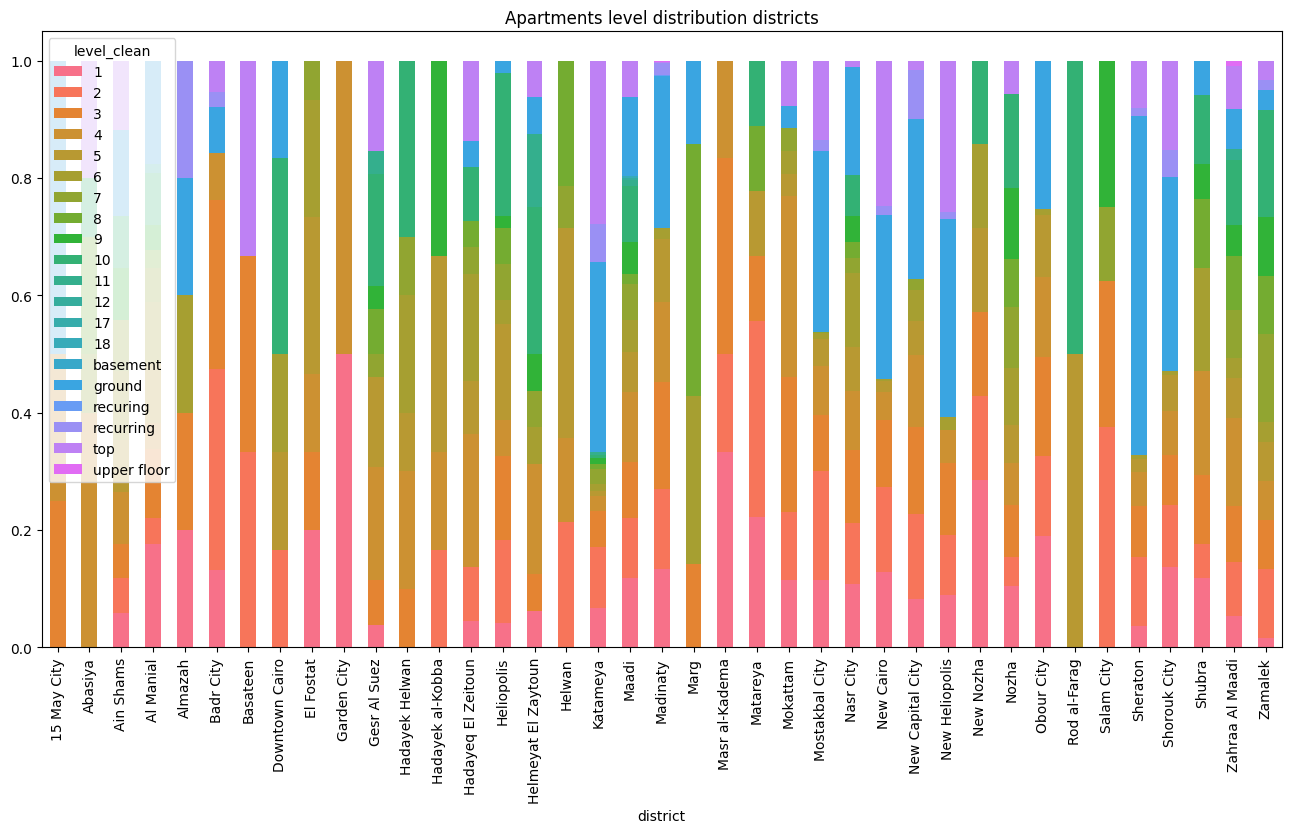

In [51]:
# Use a colormap with 25 distinct colors
import seaborn as sns
colors = sns.color_palette("husl", 23)
plot_df = data.unstack(level='level_clean').fillna(0)
plot_df = plot_df.loc[(plot_df !=0 ).any(axis=1), (plot_df !=0).any(axis=0)]
plot_df.plot(kind='bar', stacked=True, figsize=(16,8), color = colors)
# plt.tight_layout()
plt.title('Apartments level distribution districts')
plt.show()

In [44]:
df = df.drop(columns=['level', 'imputed_level'])

In [53]:
df.to_csv(config['data_source']['file_paths']['semi_cleaned_file'])

In [6]:
df = pd.read_csv(config['data_source']['file_paths']['semi_cleaned_file'])

C:\Users\marwa\AppData\Local\Temp\ipykernel_27136\1889476901.py:1: DtypeWarning: Columns (11,12,15,20,24,25,26,44) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(config['data_source']['file_paths']['semi_cleaned_file'])


In [153]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 70344 entries, 0 to 70533
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        70342 non-null  string        
 1   city                         70344 non-null  string        
 2   district                     70344 non-null  string        
 3   area                         63779 non-null  string        
 4   neighborhood                 40625 non-null  string        
 5   property_type                70344 non-null  string        
 6   sale_or_rent                 70344 non-null  string        
 7   price                        70344 non-null  Int64         
 8   seller_name                  70344 non-null  string        
 9   property_subtype             70344 non-null  string        
 10  bedrooms                     70344 non-null  string        
 11  bathrooms                    70344 non-null  s

In [45]:
# I want to count the number of private_garden where level not ground
output = df[df['level'] != 'ground']
count_private_gardens = (output['private garden'] == True).sum()
print(count_private_gardens)

34324


In [46]:
count_high_aprtments_with_garden = ((output['private garden'] == True) & (output['property_subtype'] != 'villas')).sum()
high_apartmens_with_garden = output[(output['private garden'] == True) & (output['property_subtype'] != 'villas')]


In [47]:
print(count_high_aprtments_with_garden)

34324


In [89]:
high_apartmens_with_garden.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1678 entries, 45 to 49930
Data columns (total 44 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        1678 non-null   string        
 1   city                         1678 non-null   string        
 2   district                     1678 non-null   string        
 3   area                         1274 non-null   string        
 4   neighborhood                 695 non-null    string        
 5   property_type                1678 non-null   string        
 6   sale_or_rent                 1678 non-null   string        
 7   price                        1678 non-null   Int64         
 8   seller_name                  1678 non-null   string        
 9   property_subtype             1678 non-null   string        
 10  bedrooms                     1678 non-null   string        
 11  bathrooms                    1678 non-null   s

#### Therefore, information about gardens is on the building level. As advertiser put this information for any apartment that has access to a private garden or even small landscape infornt of the buidling.


## 5. Impute: delivery term

In [ ]:

df['delivery term'].describe()

count         6840
unique           4
top       finished
freq          3790
Name: delivery term, dtype: object

In [174]:
df['delivery term'].unique()

<StringArray>
[<NA>, 'finished', 'core & shell', 'semi finished', 'not finished']
Length: 5, dtype: string

In [45]:
# title may have some information about this 
titles_has_terms_info = df[df['title'].str.contains('finished', case=False, na=False) & df['delivery term'].isnull()]
title_has_core_and_shell_info = df[df['title'].str.contains('core & shell', case=False, na=False) & df['delivery term'].isnull()]

In [177]:
titles_has_terms_info.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12903 entries, 5 to 70522
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        12903 non-null  string        
 1   city                         12903 non-null  string        
 2   district                     12903 non-null  string        
 3   area                         12648 non-null  string        
 4   neighborhood                 7904 non-null   string        
 5   property_type                12903 non-null  string        
 6   sale_or_rent                 12903 non-null  string        
 7   price                        12903 non-null  Int64         
 8   seller_name                  12903 non-null  string        
 9   property_subtype             12903 non-null  string        
 10  bedrooms                     12903 non-null  string        
 11  bathrooms                    12903 non-null  s

In [179]:
title_has_core_and_shell_info.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48 entries, 69 to 64370
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        48 non-null     string        
 1   city                         48 non-null     string        
 2   district                     48 non-null     string        
 3   area                         47 non-null     string        
 4   neighborhood                 34 non-null     string        
 5   property_type                48 non-null     string        
 6   sale_or_rent                 48 non-null     string        
 7   price                        48 non-null     Int64         
 8   seller_name                  48 non-null     string        
 9   property_subtype             48 non-null     string        
 10  bedrooms                     48 non-null     string        
 11  bathrooms                    48 non-null     str

In [63]:
for index, row in title_has_core_and_shell_info.iterrows():
    df.loc[index, 'delivery term'] = 'core & shell'
    

In [182]:
titles_has_terms_info.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12903 entries, 5 to 70522
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        12903 non-null  string        
 1   city                         12903 non-null  string        
 2   district                     12903 non-null  string        
 3   area                         12648 non-null  string        
 4   neighborhood                 7904 non-null   string        
 5   property_type                12903 non-null  string        
 6   sale_or_rent                 12903 non-null  string        
 7   price                        12903 non-null  Int64         
 8   seller_name                  12903 non-null  string        
 9   property_subtype             12903 non-null  string        
 10  bedrooms                     12903 non-null  string        
 11  bathrooms                    12903 non-null  s

In [47]:
[ 'finished', 'core & shell', 'semi finished', 'not finished']

finished = []
semi_finished = []
not_finished = []
semi_finished_pattern = r'semi[\s\-]*finished'
not_finished_pattern = r'not[\s\-]*finished'
for index, row in titles_has_terms_info.iterrows():
    title = row['title']
#     print(title)
     
    if re.search(semi_finished_pattern, row['title'], re.IGNORECASE):
         semi_finished.append(index)
         df.loc[index, 'delivery term'] = 'semi finished'
    elif re.search(not_finished_pattern, row['title'], re.IGNORECASE):
         not_finished.append(index)
         df.loc[index, 'delivery term'] = 'not finished'
    elif 'finished' in title.lower():
          finished.append(index)
          df.loc[index, 'delivery term'] = 'finished'
print(f'From 12903 that does not have delivery term we can impute {len(semi_finished)} as semi finished ')
print(f'From 12903 that does not have delivery term we can impute {len(not_finished)} as not finished ')
print(f'From 12903 that does not have delivery term we can impute {len(finished)} as  finished ')




From 12903 that does not have delivery term we can impute 892 as semi finished 
From 12903 that does not have delivery term we can impute 1 as not finished 
From 12903 that does not have delivery term we can impute 12010 as  finished 


### I managed to impute 12951  values from the title which makes the delivery term from 6840 to 19,791 still too low but I think I can get information for the arabic titles

In [48]:
# Know let's come back to the delivery term 
no_delivery_term = arabic_df[arabic_df['delivery term'].isnull()]

In [49]:
# that have some level of finish 
no_delivery_term = no_delivery_term[no_delivery_term['title'].str.contains('تشطيب' , na = False)]


In [77]:
no_delivery_term.info()

<class 'pandas.core.frame.DataFrame'>
Index: 109 entries, 23 to 70069
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        109 non-null    string        
 1   city                         109 non-null    string        
 2   district                     109 non-null    string        
 3   area                         78 non-null     string        
 4   neighborhood                 47 non-null     string        
 5   property_type                109 non-null    string        
 6   sale_or_rent                 109 non-null    string        
 7   price                        109 non-null    Int64         
 8   seller_name                  109 non-null    string        
 9   property_subtype             109 non-null    string        
 10  bedrooms                     109 non-null    string        
 11  bathrooms                    109 non-null    st

In [ ]:
# I removed the output for a cleaner notebook
no_delivery_term['title'].unique()

In [50]:


def classify_finishing(text: str) -> str:
    """
    Returns one of: 'not_finished', 'semi_finished', 'finished'
    With a sub-label for quality tier when finished.
    """
    if not isinstance(text, str):
        return 'unknown'
    
    t = text.strip()
    
    # ── NOT FINISHED ──────────────────────────────────────────
    if re.search(r'بدون\s*تشطيب', t):
        return 'not_finished'
    
    # unfurnished in English context meaning unfinished
    if re.search(r'unfurnished.*old reservation', t, re.IGNORECASE):
        return 'not_finished'
    
    # ── SEMI FINISHED ─────────────────────────────────────────
    semi_patterns = [
        r'نص\s*تشطيب',       # نص تشطيب (colloquial نص = نصف)
        r'نصف\s*تشطيب',      # نصف تشطيب
        r'semi.?finished',
        r'3\s*/\s*4\s*تشطيب',
    ]
    if any(re.search(p, t, re.IGNORECASE) for p in semi_patterns):
        return 'semi_finished'
    
    # ── FINISHED (quality tiers) ───────────────────────────────
    ultra_patterns = [
        r'الترا\s*سوبر\s*لوكس',
        r'التر\s*سوبر\s*لوكس',   # typo variant in your data
        r'ultra\s*super\s*lux',
    ]
    if any(re.search(p, t, re.IGNORECASE) for p in ultra_patterns):
        return 'finished'          # sub_tier='ultra_super_lux'
    
    high_patterns = [
        r'هاي\s*سوبر\s*لوكس',
        r'هاي\s*لوكس',
        r'high\s*super\s*lux',
    ]
    if any(re.search(p, t, re.IGNORECASE) for p in high_patterns):
        return 'finished'          # sub_tier='high_super_lux'
    
    super_lux_patterns = [
        r'سوبر\s*لوكس',
        r'سوبرلوكس',
        r'super\s*lux',
    ]
    if any(re.search(p, t, re.IGNORECASE) for p in super_lux_patterns):
        return 'finished'          # sub_tier='super_lux'
    
    hotel_patterns = [
        r'تشطيب\s*فندق[يى]',
        r'فندق[يى]\s*تشطيب',    # reversed order variant
        r'تشطيب\s*VIP',
        r'VIP\s*تشطيب',
    ]
    if any(re.search(p, t, re.IGNORECASE) for p in hotel_patterns):
        return 'finished'          # sub_tier='hotel_vip'
    
    lux_patterns = [
        r'تشطيب\s*(لوكس|الترا\s*لوكس)',
        r'لوكس\s*تشطيب',
    ]
    if any(re.search(p, t, re.IGNORECASE) for p in lux_patterns):
        return 'finished'          # sub_tier='lux'
    
    generic_finished_patterns = [
        r'تشطيب\s*كامل',
        r'كامل\s*التشطيب',
        r'كامله\s*التشطيب',
        r'بالتشطيب',
        r'تشطيب\s*(فاخر|مميز|خاص|راقي|راقٍ|جديد|ممتاز|كلاسيك)',
        r'(فاخر|مميز|خاص|راقي|ممتاز)\s*تشطيب',
        r'تشطيبات\s*(خاصة|خاصه|مميزة|راقية)',
        r'تشطيب\s*شركة',          # developer finishing
        r'تشطيب\s*مجموعة',        # e.g. تشطيبات مجموعة طلعت
        r'with\s*finishing',
        r'full\s*finishing',
        r'fully\s*(equipped|finished)',
        r'تشطيب',                  # plain تشطيب as last resort
    ]
    if any(re.search(p, t, re.IGNORECASE) for p in generic_finished_patterns):
        return 'finished'
    
    return 'unknown'




In [53]:
no_delivery_term['delivery term'] = no_delivery_term['title'].apply(classify_finishing) 

In [55]:
no_delivery_term['delivery term'].value_counts()

delivery term
finished         96
semi_finished    10
not_finished      3
Name: count, dtype: int64

In [64]:
count = 1
for index, row in no_delivery_term.iterrows():
    df.loc[index, 'delivery term'] = row['delivery term']

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 70344 entries, 0 to 70533
Data columns (total 41 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        70342 non-null  string        
 1   city                         70344 non-null  string        
 2   district                     70344 non-null  string        
 3   area                         63779 non-null  string        
 4   neighborhood                 40625 non-null  string        
 5   property_type                70344 non-null  string        
 6   sale_or_rent                 70344 non-null  string        
 7   price                        70344 non-null  Int64         
 8   seller_name                  70344 non-null  string        
 9   property_subtype             70344 non-null  string        
 10  bedrooms                     70344 non-null  string        
 11  bathrooms                    70344 non-null  s

In [66]:
df.drop(columns= ['delivery term '], inplace = True)

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 70344 entries, 0 to 70533
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        70342 non-null  string        
 1   city                         70344 non-null  string        
 2   district                     70344 non-null  string        
 3   area                         63779 non-null  string        
 4   neighborhood                 40625 non-null  string        
 5   property_type                70344 non-null  string        
 6   sale_or_rent                 70344 non-null  string        
 7   price                        70344 non-null  Int64         
 8   seller_name                  70344 non-null  string        
 9   property_subtype             70344 non-null  string        
 10  bedrooms                     70344 non-null  string        
 11  bathrooms                    70344 non-null  s

In [73]:
df.drop(columns='price type', inplace = True)

### Managed to impute 12,951 values from titles, bringing delivery term coverage from 6,840 to 19,791. 
### Still insufficient for modeling (71%+ missing) — retained for EDA only.

## 6. Impute: rental frequency

In [75]:
no_rental_frequency = df[df['rental frequency'].isnull()]
no_rental_frequency = no_rental_frequency[no_rental_frequency['sale_or_rent'] == 'rent']

In [ ]:
no_rental_frequency.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2431 entries, 37869 to 70517
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        2431 non-null   string        
 1   city                         2431 non-null   string        
 2   district                     2431 non-null   string        
 3   area                         2198 non-null   string        
 4   neighborhood                 1753 non-null   string        
 5   property_type                2431 non-null   string        
 6   sale_or_rent                 2431 non-null   string        
 7   price                        2431 non-null   Int64         
 8   seller_name                  2431 non-null   string        
 9   property_subtype             2431 non-null   string        
 10  bedrooms                     2431 non-null   string        
 11  bathrooms                    2431 non-null 

In [86]:
count = 0
for index, row in no_rental_frequency.iterrows():
    if any(word in row['title'].lower() for word in ['month', 'year', 'day', 'period']):
        count+=1
        print(f"{row['title']} In {row['district']} with price {row['price']} EGP ")
print(count)

Hotel-style apartment for monthly and daily rent In New Cairo with price 38000 EGP 
Fully furnished hotel-style apartment for monthly and daily rent Prime location In New Cairo with price 40000 EGP 
For Rent - Special Finishing Prime Location Privado 84 sq m + 35 sq m Garden Ultralux Furnished 2 Bedrooms + Bathroom On the Lakes Group 93 40 Monthly 35 for 6 Months Also Available 100 sq m Repeated Apartment On the Lakes 155 sq m Special Finishing First In Madinaty with price 35000 EGP 
Luxury serviced apartment for rent in Privado Madinaty 84 sqm first floor first use fully furnished smart home with 2 bedrooms available daily monthly In Madinaty with price 35000 EGP 
Furnished apartment for rent in JABKO compound Maadi, next to One-Day Hospital, the Ring Road and Saqer Quraish, JABKO compound In Maadi with price 12000 EGP 
For daily and monthly rent, a luxurious furnished apartment in New Maadi, next to Carrefour In Maadi with price 1500 EGP 
Apartment furnished for rent Maadi Compound G

In [87]:
df['rental frequency'].value_counts()

rental frequency
monthly    11936
daily        284
yearly        48
weekly        10
Name: count, dtype: Int64


**14k total rental properties. ~12k have frequency filled, ~2,430 missing.**<br>
**Title investigation found no usable keywords (month/year/day appeared in almost none).**<br>
**Decision: use price distribution (KDE) to determine correct imputation value**

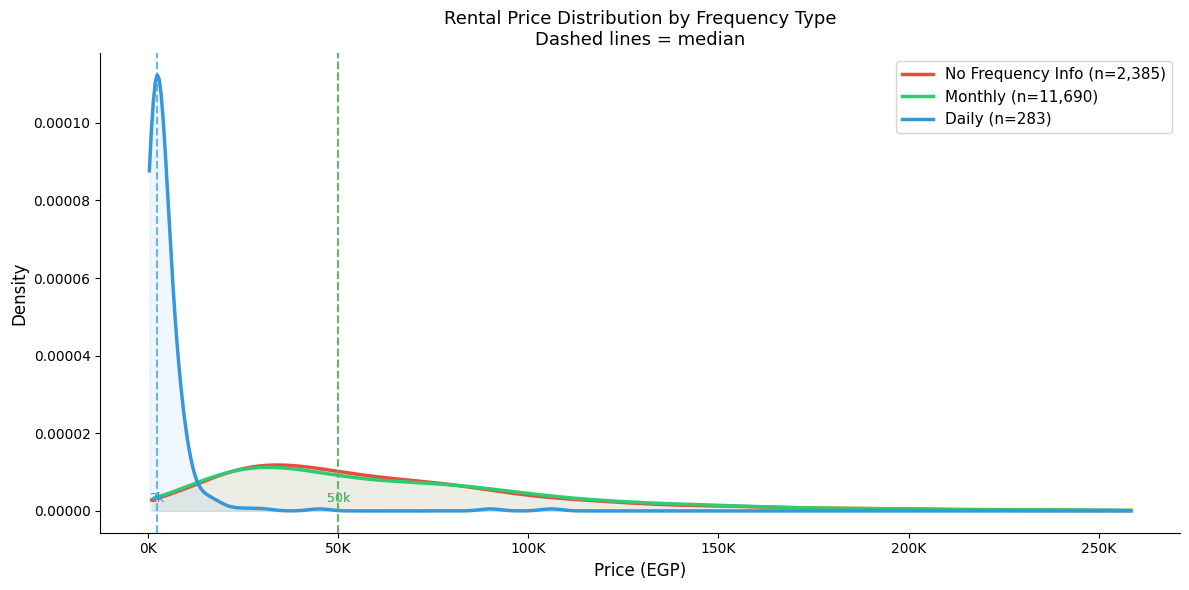

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(12, 6))

# ── Segment your three groups ─────────────────────────────────
no_freq    = no_rental_frequency['price'].dropna()
monthly    = df[df['rental frequency'] == 'monthly']['price'].dropna()
daily      = df[df['rental frequency'] == 'daily']['price'].dropna()

# ── Optional: clip extreme outliers for cleaner KDE ──────────
cap = df[df['sale_or_rent'] == 'rent']['price'].quantile(0.98)
no_freq = no_freq[no_freq <= cap]
monthly = monthly[monthly <= cap]
daily   = daily[daily <= cap]

# ── Plot KDE for each group ───────────────────────────────────
groups = [
    (no_freq, 'No Frequency Info', '#e74c3c'),
    (monthly, 'Monthly',           '#2ecc71'),
    (daily,   'Daily',             '#3498db'),
]

for data, label, color in groups:
    kde = gaussian_kde(data, bw_method=0.3)
    x = np.linspace(data.min(), cap, 500)
    ax.plot(x, kde(x), label=f'{label} (n={len(data):,})', 
            color=color, linewidth=2.5)
    ax.fill_between(x, kde(x), alpha=0.08, color=color)

# ── Add median vertical lines ─────────────────────────────────
for data, label, color in groups:
    ax.axvline(data.median(), color=color, linestyle='--', 
               linewidth=1.5, alpha=0.7)
    ax.text(data.median(), ax.get_ylim()[1] * 0.02, 
            f'{data.median()/1000:.0f}k', 
            color=color, fontsize=9, ha='center')

# ── Formatting ────────────────────────────────────────────────
ax.set_xlabel('Price (EGP)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Rental Price Distribution by Frequency Type\n'
             'Dashed lines = median', fontsize=13)
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1_000:.0f}K')
)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
# plt.savefig('rental_frequency_kde.png', dpi=150)
plt.show()

**The price distribution of unkonwn frequency is consisten with the monthly rentals, so I could impute them as monthly.**

In [95]:
no_rental_frequency['district'].value_counts()

district
New Cairo             1759
Madinaty               236
Katameya               107
Maadi                   99
Shorouk City            64
Zahraa Al Maadi         45
Nasr City               32
Al Manial               14
New Capital City        14
Nozha                   13
Zamalek                 13
Mostakbal City           8
Sheraton                 6
Mokattam                 5
New Heliopolis           4
Hadayeq El Zeitoun       4
Heliopolis               2
El Fostat                2
Downtown Cairo           2
Shubra                   1
Helwan                   1
Name: count, dtype: Int64

In [96]:
no_rental_frequency['property_type'].value_counts()

property_type
apartments    2001
villas         430
Name: count, dtype: Int64

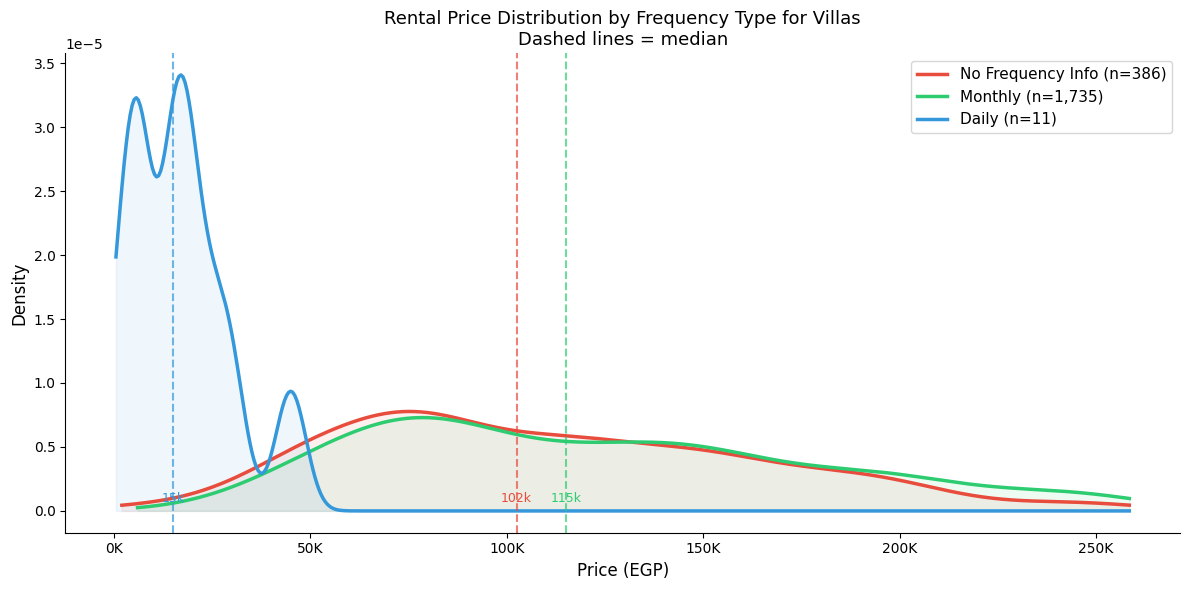

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(12, 6))

# ── Segment your three groups ─────────────────────────────────
no_freq    = no_rental_frequency[no_rental_frequency['property_type'] == 'villas']['price'].dropna()
monthly    = df[(df['rental frequency'] == 'monthly') & (df['property_type'] == 'villas')]['price'].dropna()
daily      = df[(df['rental frequency'] == 'daily') & (df['property_type'] == 'villas')]['price'].dropna()

# ── Optional: clip extreme outliers for cleaner KDE ──────────
cap = df[df['sale_or_rent'] == 'rent']['price'].quantile(0.98)
no_freq = no_freq[no_freq <= cap]
monthly = monthly[monthly <= cap]
daily   = daily[daily <= cap]

# ── Plot KDE for each group ───────────────────────────────────
groups = [
    (no_freq, 'No Frequency Info', '#e74c3c'),
    (monthly, 'Monthly',           '#2ecc71'),
    (daily,   'Daily',             '#3498db'),
]

for data, label, color in groups:
    kde = gaussian_kde(data, bw_method=0.3)
    x = np.linspace(data.min(), cap, 500)
    ax.plot(x, kde(x), label=f'{label} (n={len(data):,})', 
            color=color, linewidth=2.5)
    ax.fill_between(x, kde(x), alpha=0.08, color=color)

# ── Add median vertical lines ─────────────────────────────────
for data, label, color in groups:
    ax.axvline(data.median(), color=color, linestyle='--', 
               linewidth=1.5, alpha=0.7)
    ax.text(data.median(), ax.get_ylim()[1] * 0.02, 
            f'{data.median()/1000:.0f}k', 
            color=color, fontsize=9, ha='center')

# ── Formatting ────────────────────────────────────────────────
ax.set_xlabel('Price (EGP)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Rental Price Distribution by Frequency Type for Villas\n'
             'Dashed lines = median', fontsize=13)
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1_000:.0f}K')
)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
# plt.savefig('rental_frequency_kde.png', dpi=150)
plt.show()

### The price distribution of unknown-frequency listings is consistent with monthly rentals, so we impute them as monthly.

In [ ]:
for index,row in no_rental_frequency.iterrows():
    df.loc[index, 'rental frequency'] = 'monthly'

In [ ]:

df.info()

In [ ]:
deposit_and_insurance= df[(~df['deposit'].isnull()) & (~ df['insurance'].isnull())]

In [ ]:
deposit_and_insurance['sale_or_rent'].value_counts()

sale_or_rent
rent    2520
Name: count, dtype: Int64

In [ ]:
deposit_and_insurance['district'].value_counts()

In [115]:
df['deposit'] = df['deposit'].str.replace(',', '').replace('nan',pd.NA).astype('Int64')
df['insurance'] = df['insurance'].str.replace(',','').replace('nan', pd.NA).astype('Int64')

In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 70344 entries, 0 to 70533
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        70342 non-null  string        
 1   city                         70344 non-null  string        
 2   district                     70344 non-null  string        
 3   area                         63779 non-null  string        
 4   neighborhood                 40625 non-null  string        
 5   property_type                70344 non-null  string        
 6   sale_or_rent                 70344 non-null  string        
 7   price                        70344 non-null  Int64         
 8   seller_name                  70344 non-null  string        
 9   property_subtype             70344 non-null  string        
 10  bedrooms                     70344 non-null  string        
 11  bathrooms                    70344 non-null  s

## 7.Investigate: Delivery Date

In [ ]:
df['delivery date'].value_counts()

delivery date
nan                69352
2027                 449
2026                 214
2028                 156
2029                  93
soon                  23
2030                  19
within 6 months       13
2025                   7
2027.0                 6
2028.0                 3
2026.0                 3
7                      2
7.0                    2
13                     1
14                     1
Name: count, dtype: Int64

In [120]:
off_plan_values = ['2027', '2028', '2029', '2030', '2027.0', '2028.0']
df['is_off_plan'] = df['delivery date'].isin(off_plan_values)

In [121]:
df.drop(columns=['delivery date'], inplace = True)

## Lastly: save the cleaned dataset 
**I will save it into parquet to preserve the datatypes**

In [131]:
df.to_parquet(config['data_source']['file_paths']['cleaned_dataset'], index=False)

In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 70344 entries, 0 to 70533
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        70342 non-null  string        
 1   city                         70344 non-null  string        
 2   district                     70344 non-null  string        
 3   area                         63779 non-null  string        
 4   neighborhood                 40625 non-null  string        
 5   property_type                70344 non-null  string        
 6   sale_or_rent                 70344 non-null  string        
 7   price                        70344 non-null  Int64         
 8   seller_name                  70344 non-null  string        
 9   property_subtype             70344 non-null  string        
 10  bedrooms                     70344 non-null  string        
 11  bathrooms                    70344 non-null  s

## Cleaning Decisions Summary

| Column | Action | Reason |
|---|---|---|
| compound | Dropped | 3 non-null values, redundant with neighborhood |
| delivery date | Dropped → derived `is_off_plan` boolean | 69k nulls but non-null values indicate off-plan properties, real price signal |
| delivery term | Imputed then excluded from model | 71% missing, retained for EDA only |
| level | Imputed in 3 layers → level_clean | Went from 6k to 50k+ using subtype logic + regex |
| rental frequency | Imputed nulls as monthly | KDE confirmed distribution matches monthly |
| deposit / insurance | Kept for EDA, excluded from model | 79% missing, concentrated in New Cairo/Madinaty |
| price type | Dropped | Redundant |

## Key Takeaways

- The dataset is heavily bilingual (Arabic/English) and sometimes mixed within the same listing.
  Every extraction and imputation step had to handle both languages separately.

- Missing data is not random. Most null-heavy columns (delivery term, deposit, insurance, level)
  are missing because certain listing types or districts simply don't include that information —
  not because of scraping errors. This means dropping nulls blindly would introduce bias.

- New Cairo dominates the dataset across almost every segment. Any model trained on this data
  should be evaluated per district, not just overall, to avoid New Cairo skewing the results.

- Imputation decisions were evidence-based, not assumption-based. Every imputation 
  (level, rental frequency, delivery term) was backed by either distribution analysis, 
  domain logic, or regex extraction from titles — not filling with means or modes blindly.

- Several columns were kept for EDA and the future RAG chatbot even after being excluded 
  from the model feature matrix. The dataset is a knowledge base about Cairo rental market 
  behavior, not just a modeling input.

- The title column was the single most valuable source for imputation across the entire 
  notebook — level, delivery term, finishing, and rental frequency all drew from it.